# T03 — Image numérique, convolution et filtrage

Ce notebook accompagne le README de T03.

Objectifs expérimentaux :

- manipuler HWC, CHW et BCHW ;
- inspecter une fenêtre locale ;
- reproduire une corrélation 2D ;
- modifier le stride ;
- comparer plusieurs paddings ;
- observer passe-bas et passe-haut ;
- vérifier NumPy avec PyTorch.

Règle :

> Pour chaque expérience, écrire une prédiction avant d'exécuter le code.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

ROOT = Path.cwd()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

T03_SCRIPTS = ROOT / "scripts" / "t03"

if str(T03_SCRIPTS) not in sys.path:
    sys.path.insert(0, str(T03_SCRIPTS))

from convolution_2d_numpy import (
    correlate2d,
    output_shape_2d,
)

print("Repository root:", ROOT)
print("NumPy:", np.__version__)
print("PyTorch:", torch.__version__)

Repository root: C:\Users\blek\Documents\Doctorat\full_wcnn
NumPy: 2.5.3
PyTorch: 2.14.0+cu132


## Expérience 1 — HWC → CHW → BCHW

### Question

Une image RGB possède :

- H = 2
- W = 4
- C = 3

Quelle sera sa shape :

1. avec NumPy en HWC ?
2. après passage en CHW ?
3. après ajout d'un batch de taille 1 ?

### Prédiction

Écrire les trois shapes avant d'exécuter la cellule suivante.

In [2]:
image_hwc = np.zeros(
    (2, 4, 3),
    dtype=np.uint8,
)

tensor_hwc = torch.from_numpy(image_hwc)
tensor_chw = tensor_hwc.permute(2, 0, 1)
tensor_bchw = tensor_chw.unsqueeze(0)

print("NumPy HWC :", image_hwc.shape)
print("Torch HWC :", tuple(tensor_hwc.shape))
print("Torch CHW :", tuple(tensor_chw.shape))
print("Torch BCHW:", tuple(tensor_bchw.shape))

NumPy HWC : (2, 4, 3)
Torch HWC : (2, 4, 3)
Torch CHW : (3, 2, 4)
Torch BCHW: (1, 3, 2, 4)


### Observation

Comparer les shapes obtenues aux prédictions.

### Interprétation

`permute(2, 0, 1)` ne modifie pas les valeurs des pixels : il modifie l'ordre des axes.

`unsqueeze(0)` ajoute une nouvelle dimension en première position.

À retenir :

```text
HWC
→ permute
→ CHW
→ unsqueeze
→ BCHW

## Expérience 2 — Une seule fenêtre de corrélation

Nous utilisons :

```text
I =
[
  [1,2,3,4],
  [5,6,7,8],
  [9,10,11,12],
  [13,14,15,16]
]

K =
[
  [1,0],
  [0,-1]
]
```

### Question

Quelle doit être la première valeur de sortie ?

### Prédiction

Calculer sur papier :

```text
1 × ?
+ 2 × ?
+ 5 × ?
+ 6 × ?
```

In [3]:
image = np.array(
    [
        [1, 2, 3, 4],
        [5, 6, 7, 8],
        [9, 10, 11, 12],
        [13, 14, 15, 16],
    ],
    dtype=np.float64,
)

kernel = np.array(
    [
        [1, 0],
        [0, -1],
    ],
    dtype=np.float64,
)

window = image[0:2, 0:2]
products = window * kernel
manual_value = products.sum()

print("Window:")
print(window)

print("\nKernel:")
print(kernel)

print("\nWindow × kernel:")
print(products)

print("\nSum:")
print(manual_value)

Window:
[[1. 2.]
 [5. 6.]]

Kernel:
[[ 1.  0.]
 [ 0. -1.]]

Window × kernel:
[[ 1.  0.]
 [ 0. -6.]]

Sum:
-5.0


### Observation

La première fenêtre doit produire `-5`.

### Interprétation

Une seule valeur de sortie correspond à :

```text
fenêtre locale
× kernel
→ multiplication élément par élément
→ somme
```

Le reste de la corrélation consiste simplement à répéter ce calcul à d'autres positions.

## Expérience 3 — Déplacement du kernel

### Question

Les trois fenêtres de la première ligne de sortie doivent-elles produire des valeurs différentes ?

### Prédiction

Calculer mentalement ou sur papier les trois résultats avant l'exécution.

In [5]:
kernel_height, kernel_width = kernel.shape

for x in range(3):
    window = image[
        0:kernel_height,
        x:x + kernel_width,
    ]

    value = np.sum(window * kernel)

    print(f"\nx = {x}")
    print(window)
    print("result =", value)

full_result = correlate2d(
    image,
    kernel,
    stride=1,
    padding=0,
)

print("\nFull result:")
print(full_result)


x = 0
[[1. 2.]
 [5. 6.]]
result = -5.0

x = 1
[[2. 3.]
 [6. 7.]]
result = -5.0

x = 2
[[3. 4.]
 [7. 8.]]
result = -5.0

Full result:
[[-5. -5. -5.]
 [-5. -5. -5.]
 [-5. -5. -5.]]


## Expérience 4 — Effet du stride

### Question

Avec :

```text
image = 4 × 4
kernel = 2 × 2
padding = 0
```

quelle sera la taille de sortie pour :

```text
stride = 1
stride = 2
```

### Prédiction

Utiliser :

$$
H_{out}
=
\left\lfloor
\frac{H + 2P - K}{S}
\right\rfloor + 1
$$

avant d'exécuter.

In [7]:
shape_stride_1 = output_shape_2d(
    image_shape=image.shape,
    kernel_shape=kernel.shape,
    stride=1,
    padding=0,
)

shape_stride_2 = output_shape_2d(
    image_shape=image.shape,
    kernel_shape=kernel.shape,
    stride=2,
    padding=0,
)

result_stride_1 = correlate2d(
    image,
    kernel,
    stride=1,
)

result_stride_2 = correlate2d(
    image,
    kernel,
    stride=2,
)

print("Predicted shape stride 1:", shape_stride_1)
print(result_stride_1)

print("\nPredicted shape stride 2:", shape_stride_2)
print(result_stride_2)

Predicted shape stride 1: (3, 3)
[[-5. -5. -5.]
 [-5. -5. -5.]
 [-5. -5. -5.]]

Predicted shape stride 2: (2, 2)
[[-5. -5.]
 [-5. -5.]]


### Observation et interprétation

Avec un stride plus grand :

- le kernel visite moins de positions ;
- la sortie possède moins d'éléments ;
- certaines positions intermédiaires ne sont jamais utilisées comme origine de fenêtre.

Le stride ne modifie pas le kernel.

Il modifie son déplacement.

## Expérience 5 — Padding

Considérons :

```text
[10, 20, 30]
```

avec un padding d'une valeur.

### Question

Que doit produire :

* zero padding ?
* reflect padding ?
* replicate padding ?

### Prédiction

Dessiner les trois lignes avant l'exécution.

In [14]:
line = np.array(
    [10, 20, 30],
    dtype=np.float64,
)

zero = np.pad(
    line,
    pad_width=1,
    mode="constant",
    constant_values=0,
)

reflect = np.pad(
    line,
    pad_width=1,
    mode="reflect",
)

replicate = np.pad(
    line,
    pad_width=1,
    mode="edge",
)

print("Original :", line)
print("Zero     :", zero)
print("Reflect  :", reflect)
print("Replicate:", replicate)

Original : [10. 20. 30.]
Zero     : [ 0. 10. 20. 30.  0.]
Reflect  : [20. 10. 20. 30. 20.]
Replicate: [10. 10. 20. 30. 30.]


### Observation et interprétation

Le contenu central reste le même.

Seules les valeurs supposées exister à l'extérieur changent.

Ces valeurs influencent ensuite les fenêtres situées près des limites.

Le choix du traitement des bords peut donc modifier les coefficients calculés près des contours de l'image.

## Expérience 6 — Passe-bas et passe-haut

### Question

Sur une image contenant un rectangle clair sur fond sombre :

1. où le filtre moyenneur modifiera-t-il principalement l'image ?
2. où le filtre de variation produira-t-il les plus fortes réponses ?

### Prédiction

Formuler la réponse avant d'exécuter.

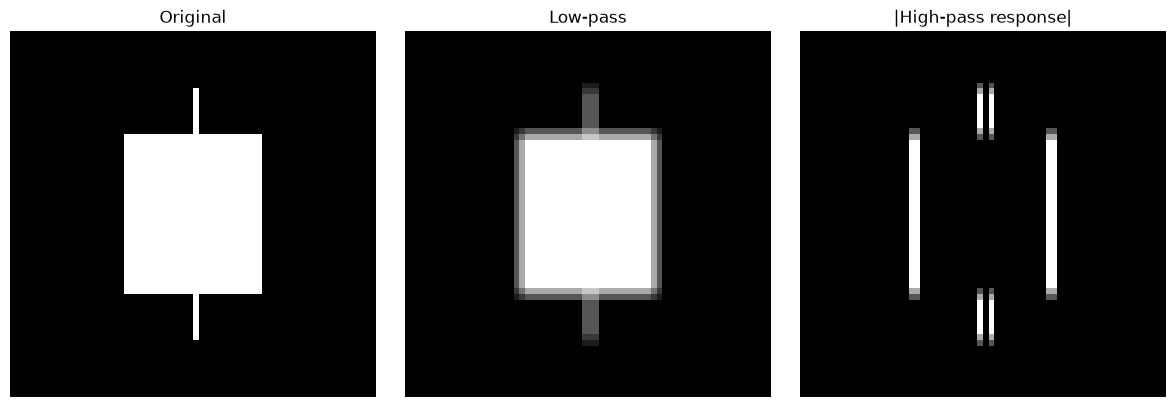

In [15]:
synthetic = np.zeros(
    (64, 64),
    dtype=np.float64,
)

synthetic[18:46, 20:44] = 1.0
synthetic[10:54, 32] = 1.0

low_kernel = np.ones(
    (3, 3),
    dtype=np.float64,
) / 9.0

high_kernel = np.array(
    [
        [-1, 0, 1],
        [-1, 0, 1],
        [-1, 0, 1],
    ],
    dtype=np.float64,
)

low = correlate2d(
    synthetic,
    low_kernel,
    padding=1,
    padding_mode="reflect",
)

high = correlate2d(
    synthetic,
    high_kernel,
    padding=1,
    padding_mode="reflect",
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(12, 4),
)

axes[0].imshow(
    synthetic,
    cmap="gray",
    vmin=0,
    vmax=1,
)
axes[0].set_title("Original")

axes[1].imshow(
    low,
    cmap="gray",
    vmin=0,
    vmax=1,
)
axes[1].set_title("Low-pass")

axes[2].imshow(
    np.abs(high),
    cmap="gray",
)
axes[2].set_title("|High-pass response|")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

### Observation

Le passe-bas :

- lisse les transitions ;
- diffuse localement les intensités.

Le filtre de variation :

- répond fortement autour de certaines transitions ;
- reste faible dans les zones constantes.

### Interprétation

Une réponse haute fréquence peut provenir :

- d'un contour ;
- d'une texture ;
- d'un détail ;
- de bruit.

Il serait donc incorrect de conclure :

```text
haute fréquence = information utile
```

In [16]:
# Expérience 7 — NumPy vs PyTorch
#
# Question :
# PyTorch doit-il produire la même matrice que notre implémentation NumPy ?
#
# Prédiction :
# Écrire la matrice attendue avant l'exécution.

numpy_result = correlate2d(
    image,
    kernel,
    stride=1,
    padding=0,
)

image_torch = torch.tensor(
    image,
    dtype=torch.float32,
).unsqueeze(0).unsqueeze(0)

kernel_torch = torch.tensor(
    kernel,
    dtype=torch.float32,
).unsqueeze(0).unsqueeze(0)

torch_result = F.conv2d(
    image_torch,
    kernel_torch,
    stride=1,
    padding=0,
)

torch_result_hw = torch_result.squeeze(0).squeeze(0)

expected_from_numpy = torch.tensor(
    numpy_result,
    dtype=torch.float32,
)

print("NumPy:")
print(numpy_result)

print("\nPyTorch:")
print(torch_result_hw)

print(
    "\ntorch.allclose =",
    torch.allclose(
        torch_result_hw,
        expected_from_numpy,
    ),
)

assert torch.allclose(
    torch_result_hw,
    expected_from_numpy,
)

print("\nObservation : NumPy et PyTorch produisent le même résultat.")
print(
    "Interprétation : F.conv2d automatise le mécanisme "
    "que nous avons calculé manuellement."
)

NumPy:
[[-5. -5. -5.]
 [-5. -5. -5.]
 [-5. -5. -5.]]

PyTorch:
tensor([[-5., -5., -5.],
        [-5., -5., -5.],
        [-5., -5., -5.]])

torch.allclose = True

Observation : NumPy et PyTorch produisent le même résultat.
Interprétation : F.conv2d automatise le mécanisme que nous avons calculé manuellement.
